# Macenco normalization

If you have no cl compiler you should download Visual Studio Installer build tools via Visual Studio Installer. <br>
I strongly recomend you make flat field correction of the slide before Machenco normalization. It wil dramaticaly impove the result. <br>
You can do it via BioVoxel plugin for ImageJ (also known as Fiji). Use pseudo flat-field correction


In [1]:
# import libraries 
# sorry for not making imports in first cell
# it is needed because you have to aclivate cl.exe before importing torch

import os
import subprocess
import shutil
import tempfile
from pathlib import Path
import sys
import platform

## Activation of cl.exe

***First make sure that you use 64 bit cl compiler with 64 bit Windows*** <br>
Otherwise nothing will work properly 


In [6]:
print("Python executable:", sys.executable)
print("cl.exe found by Python:", shutil.which("cl"))
print(platform.architecture())

Python executable: c:\Users\Yaroslav\AppData\Local\Programs\Python\Python310\python.exe
cl.exe found by Python: C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\VC\Tools\MSVC\14.51.36231\bin\HostX64\x64\cl.EXE
('64bit', 'WindowsPE')


In [3]:
VCVARS64 = Path(
    r"C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools"
    r"\VC\Auxiliary\Build\vcvars64.bat"
)

if not VCVARS64.is_file():
    raise FileNotFoundError(f"Not found:\n{VCVARS64}")

# A .cmd file avoids cmd.exe nested quote parsing problems
with tempfile.NamedTemporaryFile(
    mode="w",
    suffix=".cmd",
    encoding="utf-8",
    delete=False
) as f:
    batch_path = Path(f.name)

    f.write("@echo off\n")
    f.write(f'call "{VCVARS64}"\n')
    f.write("echo __VCVARS_FINISHED__\n")
    f.write("set\n")
    f.write("exit /b %ERRORLEVEL%\n")

try:
    result = subprocess.run(
        ["cmd.exe", "/d", "/c", str(batch_path)],
        capture_output=True,
        text=True,
        encoding="cp866",
        errors="replace",
        check=False
    )
finally:
    batch_path.unlink(missing_ok=True)

print("Return code:", result.returncode)
print("\n--- STDERR ---")
print(result.stderr[-2000:])

print("\n--- Last STDOUT lines ---")
print("\n".join(result.stdout.splitlines()[-20:]))

Return code: 0

--- STDERR ---


--- Last STDOUT lines ---
VSCODE_CODE_CACHE_PATH=C:\Users\Yaroslav\AppData\Roaming\Code\CachedData\08d4889f9ec4a1685d257b9b95de036c8e1ce1e5
VSCODE_CRASH_REPORTER_PROCESS_TYPE=extensionHost
VSCODE_CWD=C:\Users\Yaroslav\AppData\Local\Programs\Microsoft VS Code
VSCODE_ESM_ENTRYPOINT=vs/workbench/api/node/extensionHostProcess
VSCODE_HANDLES_UNCAUGHT_ERRORS=true
VSCODE_IPC_HOOK=\\.\pipe\ecd73801-1.135.0-main-sock
VSCODE_L10N_BUNDLE_LOCATION=
VSCODE_NLS_CONFIG={"userLocale":"en-us","osLocale":"en-us","resolvedLanguage":"en","defaultMessagesFile":"C:\\Users\\Yaroslav\\AppData\\Local\\Programs\\Microsoft VS Code\\08d4889f9e\\resources\\app\\out\\nls.messages.json","locale":"en-us","availableLanguages":{}}
VSCODE_PID=15476
VSINSTALLDIR=C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\
WINDIR=C:\WINDOWS
WindowsLibPath=C:\Program Files (x86)\Windows Kits\10\UnionMetadata\10.0.26100.0;C:\Program Files (x86)\Windows Kits\10\References\10.0.26100.0
Window

***If your output looks like this, you doing it right***

Return code: 0

--- STDERR ---


--- Last STDOUT lines ---
VSCMD_VER=18.9.2
VSCODE_CODE_CACHE_PATH=C:\Users\Yaroslav\AppData\Roaming\Code\CachedData\110a328ea54b42367b803ec53ee0bf52ef26b419
VSCODE_CRASH_REPORTER_PROCESS_TYPE=extensionHost
VSCODE_CWD=C:\Users\Yaroslav\AppData\Local\Programs\Microsoft VS Code
VSCODE_ESM_ENTRYPOINT=vs/workbench/api/node/extensionHostProcess
VSCODE_HANDLES_UNCAUGHT_ERRORS=true
VSCODE_IPC_HOOK=\\.\pipe\ecd73801-1.134.0-main-sock
VSCODE_NLS_CONFIG={"userLocale":"en-us","osLocale":"en-us","resolvedLanguage":"en","defaultMessagesFile":"C:\\Users\\Yaroslav\\AppData\\Local\\Programs\\Microsoft VS Code\\110a328ea5\\resources\\app\\out\\nls.messages.json","locale":"en-us","availableLanguages":{}}
VSCODE_PID=4564
VSINSTALLDIR=C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\
WINDIR=C:\WINDOWS
WindowsLibPath=C:\Program Files (x86)\Windows Kits\10\UnionMetadata\10.0.26100.0;C:\Program Files (x86)\Windows Kits\10\References\10.0.26100.0
WindowsSdkBinPath=C:\Program Files (x86)\Windows Kits\10\bin\
WindowsSdkDir=C:\Program Files (x86)\Windows Kits\10\
WindowsSDKLibVersion=10.0.26100.0\
WindowsSdkVerBinPath=C:\Program Files (x86)\Windows Kits\10\bin\10.0.26100.0\
WindowsSDKVersion=10.0.26100.0\
__DOTNET_ADD_64BIT=1
__DOTNET_PREFERRED_BITNESS=64


In [4]:
loaded = 0
start_reading = False

for line in result.stdout.splitlines():
    if line.strip() == "__VCVARS_FINISHED__":
        start_reading = True
        continue

    if not start_reading or "=" not in line:
        continue

    key, value = line.split("=", 1)

    if key.upper() in {
        "PATH", "INCLUDE", "LIB", "LIBPATH",
        "VCTOOLSINSTALLDIR", "VCINSTALLDIR",
        "WINDOWSSDKDIR", "WINDOWSSDKLIBVERSION",
        "UCRTCONTENTSROOT", "UCRTVERSION",
        "UNIVERSALCRTSKDIR"
    }:
        os.environ[key] = value
        loaded += 1

print("Variables imported:", loaded)
print("cl.exe found:", shutil.which("cl"))
print("INCLUDE set:", bool(os.environ.get("INCLUDE")))
print("LIB set:", bool(os.environ.get("LIB")))
print("VCToolsInstallDir:", os.environ.get("VCToolsInstallDir"))

Variables imported: 9
cl.exe found: C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\VC\Tools\MSVC\14.51.36231\bin\HostX64\x64\cl.EXE
INCLUDE set: True
LIB set: True
VCToolsInstallDir: C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\VC\Tools\MSVC\14.51.36231\


***Output should look smth like this***

Variables imported: 9 <br>
cl.exe found: C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\VC\Tools\MSVC\14.51.36231\bin\HostX64\x64\cl.EXE <br>
INCLUDE set: True <br>
LIB set: True <br>
VCToolsInstallDir: C:\Program Files (x86)\Microsoft Visual Studio\18\BuildTools\VC\Tools\MSVC\14.51.36231\ 

In [5]:
# final check that cl compailer is ready to use 
compiler_test = subprocess.run(
    ["cl"],
    capture_output=True,
    text=True,
    encoding="cp866",
    errors="replace"
)

print((compiler_test.stdout + compiler_test.stderr)[:1000])

использование: cl [ параметр... ] имя_файла... [ /link параметр_компоновки... ]
Microsoft (R) C/C++ Optimizing Compiler Version 19.51.36256 for x64
(C) Корпорация Майкрософт (Microsoft Corporation).  Все права защищены.




***Output smth like this (sorry for Russian. I have Russian version of Windows)***

использование: cl [ параметр... ] имя_файла... [ /link параметр_компоновки... ] <br>
Microsoft (R) C/C++ Optimizing Compiler Version 19.51.36256 for x64 <br>
(C) Корпорация Майкрософт (Microsoft Corporation).  Все права защищены. <br>


## Macenco alhorithm (finally)

In [21]:
# import packeges for Marcenco normalisation 
import numpy as np
from pathlib import Path
import torch
import torchstain
from PIL import Image
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch_staintools.normalizer import NormalizerBuilder

import matplotlib.pyplot as plt

For Macenco normalisation of the slide you will need referance. <br>
I recomend you to use a crop of the slide 512x512 pixels or larger. <br>
It should have no large ammount of background (but a little better be; lumen of the vessel, for example)<br>
Of course there should be no brightness gradients or other artifacts. <br>
For HNE staining, hematoxylin stained tissue, as well as eosin stained, should be visible in reference 


In [41]:
# set path to our reference, picture and output
REFERENCE_PATH =  Path.cwd().parent / "full_view" / "wistar_10x_ff_ref.tif"   
SOURCE_PATH =  Path.cwd().parent / "full_view" / "wistar_10x_ff.tif"
OUTPUT_PATH =  Path.cwd().parent / "full_view" / "wistar_10x_ff_norm.tif"

reference_rgb = np.asarray(Image.open(REFERENCE_PATH).convert("RGB"))
source_rgb = np.asarray(Image.open(SOURCE_PATH).convert("RGB"))



print("Reference:", reference_rgb.shape, reference_rgb.dtype,
      reference_rgb.min(), reference_rgb.max())

print("Source:", source_rgb.shape, source_rgb.dtype,
      source_rgb.min(), source_rgb.max())

Reference: (512, 512, 3) uint8 1 255
Source: (11704, 4488, 3) uint8 0 255


***Output should be smth like this***

Reference: (512, 512, 3) uint8 0 255 <br>
Source: (4306, 1772, 3) uint8 0 255 <br>

**Make sure that min value is 0 and max value is 255**

In [42]:
# Set device (better use GPU, but CPU is fine for small pictures and small ammount of iterations)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


In [43]:
# Create tensors
to_tensor = ToTensor()

reference_tensor = to_tensor(reference_rgb).unsqueeze(0).float().to(device)
source_tensor = to_tensor(source_rgb).unsqueeze(0).float().to(device)

print("Reference tensor:", reference_tensor.shape,
      reference_tensor.dtype,
      reference_tensor.min().item(),
      reference_tensor.max().item())

print("Source tensor:", source_tensor.shape,
      source_tensor.dtype,
      source_tensor.min().item(),
      source_tensor.max().item())

Reference tensor: torch.Size([1, 3, 512, 512]) torch.float32 0.003921568859368563 1.0
Source tensor: torch.Size([1, 3, 11704, 4488]) torch.float32 0.0 1.0


In [44]:
# Create normalizer 
normalizer = NormalizerBuilder.build(
    "macenko",
    use_cache=True,
    maxiter=100, # You can play with different number of iterations for better result
    concentration_solver="qr" # you can also use 'ls' solver but only if qr fails or take too much time
).to(device)

# Fit normalizer 
normalizer.fit(reference_tensor)

with torch.no_grad():
    normalized_tensor = normalizer(source_tensor)

print("Output tensor:", normalized_tensor.shape)
print("Output range:",
      normalized_tensor.min().item(),
      normalized_tensor.max().item())

check = (normalized_tensor.shape[2], 
         normalized_tensor.shape[3], 
         normalized_tensor.shape[1])

Output tensor: torch.Size([1, 3, 11704, 4488])
Output range: 1.683434675214812e-05 1.0


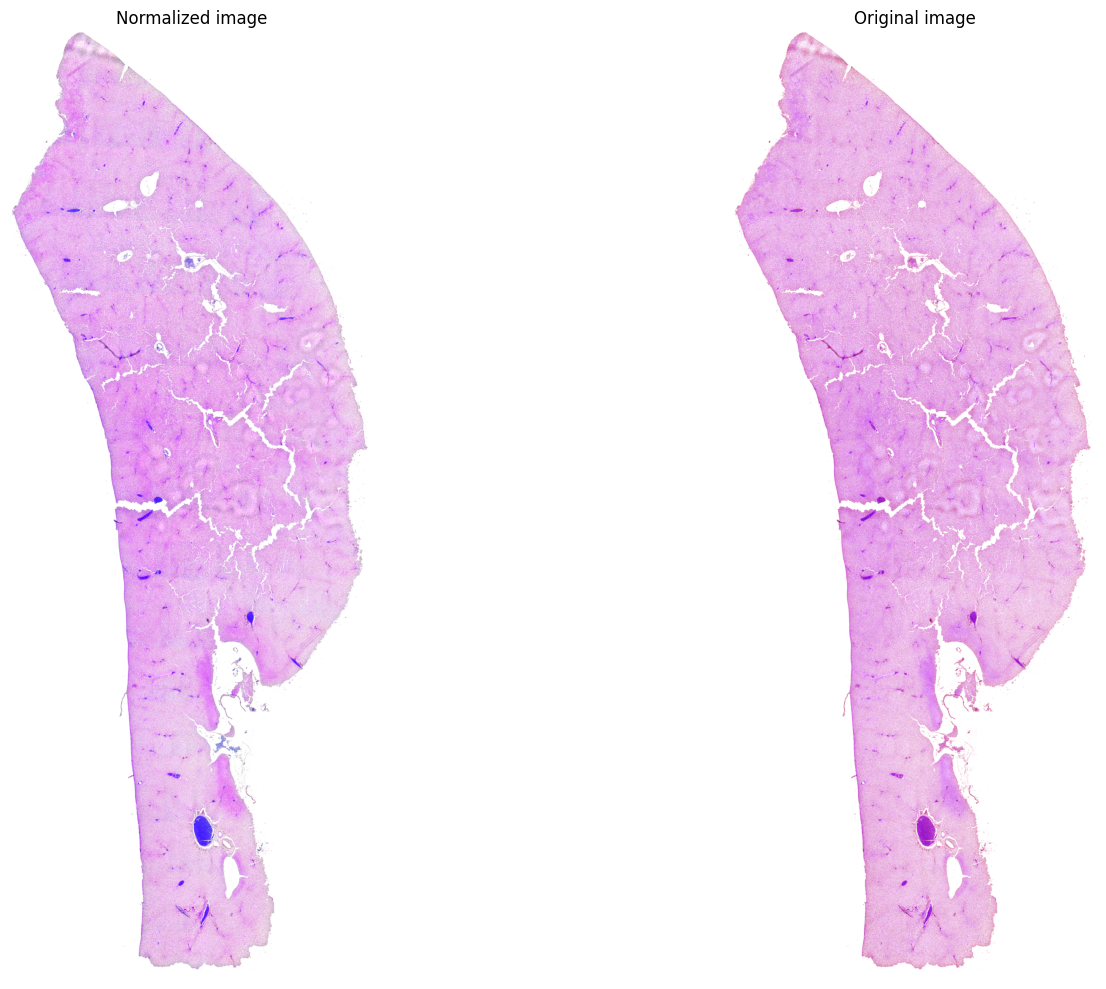

In [ ]:
# Create image back from tensor 
normalized_rgb = (
    normalized_tensor
    .squeeze(0)             # C, H, W
    .permute(1, 2, 0)       # H, W, C
    .clamp(0, 1)
    .mul(255)
    .byte()
    .cpu()
    .numpy()
)



In [46]:
# Save the image
print("Final RGB shape:", normalized_rgb.shape)
print("Final RGB dtype:", normalized_rgb.dtype)

assert normalized_rgb.shape == (check)
assert normalized_rgb.dtype == np.uint8

Image.fromarray(normalized_rgb, mode="RGB").save(
    OUTPUT_PATH,
    compression="tiff_deflate"
)

print(f"Saved: {OUTPUT_PATH}")

Final RGB shape: (11704, 4488, 3)
Final RGB dtype: uint8
Saved: c:\Users\Yaroslav\Desktop\Python_repos\Python_projects_ICG_SB_RAS\Four_host_species_OF\full_view\wistar_10x_ff_norm.tif


***DONE! You are Great!***